# VOLTA · 01 — Exploratory Data Analysis

**Spain electricity market · 2015–2018 · ENTSO-E / Red Eléctrica / OpenWeather**

Phase 1 of the trading desk. Goal: know this market well enough to explain every later modelling choice in one sentence.

This notebook does three things, in order:

1. **1A First contact** — load, column audit, missingness, timezone/DST
2. **1B Cleaning** — drop dead columns, short-gap interpolate, population-weighted weather, merge, parquet
3. **1C Insight charts** — six (plus one) figures that become the case study

Rules we will not break later: no random splits on this series, no future information in features, every number in the README must come from a pipeline that starts here.

Data stays in `data/raw/` (git-ignored). The tidy output is `data/processed/market.parquet`.


### How to run

From the repo root (data already sitting in `data/raw/`):

```bash
pip install -r requirements-dev.txt
jupyter notebook notebooks/01_eda.ipynb
```

Kernel working directory can be the repo root *or* `notebooks/` — the setup cell resolves `ROOT` either way.


In [1]:
%matplotlib inline

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Resolve repo root whether this kernel started in notebooks/ or at the project root.
ROOT = Path.cwd()
if not (ROOT / "src" / "config.py").exists():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "config.py").exists():
            ROOT = p
            break
sys.path.insert(0, str(ROOT))

from src.config import ENERGY_CSV, WEATHER_CSV, PROCESSED, CITY_WEIGHTS, RAW

FIG = ROOT / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

print("ROOT        :", ROOT)
print("energy csv  :", ENERGY_CSV, "exists=", ENERGY_CSV.exists())
print("weather csv :", WEATHER_CSV, "exists=", WEATHER_CSV.exists())
print("city weights:", CITY_WEIGHTS)
print("weights sum :", sum(CITY_WEIGHTS.values()))

# VOLTA plot defaults — readable on GitHub, on-brand in the app.
TEAL = "#0D9488"
AMBER = "#D97706"
NAVY = "#0F172A"
SLATE = "#64748B"
COAL = "#57534E"
GAS = "#EA580C"
WIND = "#0284C7"
SOLAR = "#EAB308"
HYDRO = "#2563EB"
NUKE = "#7C3AED"
RED = "#DC2626"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#E2E8F0",
    "axes.grid": True,
    "grid.color": "#F1F5F9",
    "grid.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "legend.frameon": False,
})


def savefig(fig, name: str):
    path = FIG / name
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    print("saved", path.relative_to(ROOT))


ROOT        : /home/user
energy csv  : /home/user/data/raw/energy_dataset.csv exists= True
weather csv : /home/user/data/raw/weather_features.csv exists= True
city weights: {'Madrid': 0.28, 'Barcelona': 0.27, 'Valencia': 0.22, 'Seville': 0.13, 'Bilbao': 0.1}
weights sum : 1.0


---
## 1A · First contact

Load the energy file only. Weather waits until we understand the market columns — joining too early hides problems.


In [2]:
energy = pd.read_csv(ENERGY_CSV)
print("shape :", energy.shape)
print("rows × cols expected 35064 × 29")
display(energy.head(3))
print()
energy.info()


shape : (35064, 29)
rows × cols expected 35064 × 29


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.00,329.00,0.00,"4,844.00","4,821.00",162.00,0.00,0.00,0.00,NaN,863.00,"1,051.00","1,899.00",0.00,"7,096.00",43.00,73.00,49.00,196.00,0.00,"6,378.00",17.00,NaN,"6,436.00","26,118.00","25,385.00",50.10,65.41
1,2015-01-01 01:00:00+01:00,449.00,328.00,0.00,"5,196.00","4,755.00",158.00,0.00,0.00,0.00,NaN,920.00,"1,009.00","1,658.00",0.00,"7,096.00",43.00,71.00,50.00,195.00,0.00,"5,890.00",16.00,NaN,"5,856.00","24,934.00","24,382.00",48.10,64.92
2,2015-01-01 02:00:00+01:00,448.00,323.00,0.00,"4,857.00","4,581.00",157.00,0.00,0.00,0.00,NaN,"1,164.00",973.00,"1,371.00",0.00,"7,099.00",43.00,73.00,50.00,196.00,0.00,"5,461.00",8.00,NaN,"5,454.00","23,515.00","22,734.00",47.33,64.48



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 1

**First read.** 35,064 hourly rows, 29 columns, 1 January 2015 00:00 → 31 December 2018 23:00. `time` is still a string. Several generation columns are `float64` with NaNs. Two columns look completely empty even from `.info()` (`generation hydro pumped storage aggregated`, `forecast wind offshore eday ahead`) — we confirm that next.


### Column audit

Every column, in our own words. This is the glossary we will reuse in interviews.


In [3]:
COLUMN_AUDIT = [
    # name, unit, when is it known?, what it actually is
    ("time", "ISO + offset", "now", "Hour start. Offsets are already CET/CEST (+01:00 / +02:00), not naive UTC."),
    ("generation biomass", "MW", "ex-post", "Solid biomass / biogas plants. Small, stable baseload (~300–500 MW)."),
    ("generation fossil brown coal/lignite", "MW", "ex-post", "Lignite. Inflexible, dirty, declining through the window."),
    ("generation fossil coal-derived gas", "MW", "ex-post", "DEAD. All zeros — Spain does not report this source."),
    ("generation fossil gas", "MW", "ex-post", "CCGT. The flexible price-setter. Spikes when the stack is tight."),
    ("generation fossil hard coal", "MW", "ex-post", "Hard coal. Mid-merit, structurally declining 2015→2018."),
    ("generation fossil oil", "MW", "ex-post", "Fuel-oil peakers. Tiny, expensive, rarely material."),
    ("generation fossil oil shale", "MW", "ex-post", "DEAD. All zeros."),
    ("generation fossil peat", "MW", "ex-post", "DEAD. All zeros."),
    ("generation geothermal", "MW", "ex-post", "DEAD. All zeros — Spain has no grid-scale geothermal."),
    ("generation hydro pumped storage aggregated", "MW", "ex-post", "DEAD. Entirely NaN. The useful pumped-hydro column is 'consumption'."),
    ("generation hydro pumped storage consumption", "MW", "ex-post", "Electricity *used* to pump water up. A demand, not supply. The grid's existing battery."),
    ("generation hydro run-of-river and poundage", "MW", "ex-post", "RoR hydro. Weather-driven, limited dispatchability."),
    ("generation hydro water reservoir", "MW", "ex-post", "Reservoir hydro. Dispatchable. 2017 drought vs 2016 wet year will matter."),
    ("generation marine", "MW", "ex-post", "DEAD. All zeros — no tidal/wave at this scale."),
    ("generation nuclear", "MW", "ex-post", "Nuclear. ~6 GW baseload, almost flat. The floor of the stack."),
    ("generation other", "MW", "ex-post", "Unspecified other thermal. Tiny."),
    ("generation other renewable", "MW", "ex-post", "Small renewables not in wind/solar/hydro/biomass."),
    ("generation solar", "MW", "ex-post", "PV + CSP. Night hours are *not* zero — Spain's CSP with storage still generates after sunset."),
    ("generation waste", "MW", "ex-post", "Waste-to-energy. Small baseload."),
    ("generation wind offshore", "MW", "ex-post", "DEAD. All zeros — Spain had no offshore wind in 2015–18."),
    ("generation wind onshore", "MW", "ex-post", "Onshore wind. Largest renewable. The main depressant of price."),
    ("forecast solar day ahead", "MW", "D-1 12:00", "TSO solar forecast. Known when we trade day-ahead. Legal feature — no leakage."),
    ("forecast wind offshore eday ahead", "MW", "D-1", "DEAD. Entirely NaN."),
    ("forecast wind onshore day ahead", "MW", "D-1 12:00", "TSO wind forecast. Known day-ahead. Legal feature."),
    ("total load forecast", "MW", "D-1 12:00", "TSO demand forecast. Very accurate (~1% MAPE). Hard to beat, not our headline."),
    ("total load actual", "MW", "ex-post", "Realised national demand. Target for the load model."),
    ("price day ahead", "€/MWh", "D-1 ~12:00", "TSO / OMIE day-ahead price *forecast* (not the clearing price). THIS is the benchmark we have to beat."),
    ("price actual", "€/MWh", "ex-post", "Realised spot price. Primary forecasting target."),
]

audit = pd.DataFrame(COLUMN_AUDIT, columns=["column", "unit", "known_when", "meaning"])
audit["dtype"] = audit["column"].map(energy.dtypes.astype(str))
audit["n_missing"] = audit["column"].map(energy.isna().sum())
audit["n_nonzero"] = [
    int((energy[c].fillna(0) != 0).sum()) if c != "time" else energy[c].nunique()
    for c in audit["column"]
]
display(audit)

print()
print("DEAD columns (no information):")
dead = audit.loc[audit["n_nonzero"] == 0, "column"].tolist()
print(dead)


,column,unit,known_when,meaning,dtype,n_missing,n_nonzero
0,time,ISO + offset,now,Hour start. Offsets are already CET/CEST (+01:...,object,0,35064
1,generation biomass,MW,ex-post,"Solid biomass / biogas plants. Small, stable b...",float64,19,35041
2,generation fossil brown coal/lignite,MW,ex-post,"Lignite. Inflexible, dirty, declining through ...",float64,18,24529
3,generation fossil coal-derived gas,MW,ex-post,DEAD. All zeros — Spain does not report this s...,float64,18,0
4,generation fossil gas,MW,ex-post,CCGT. The flexible price-setter. Spikes when t...,float64,18,35045
5,generation fossil hard coal,MW,ex-post,"Hard coal. Mid-merit, structurally declining 2...",float64,18,35043
6,generation fossil oil,MW,ex-post,"Fuel-oil peakers. Tiny, expensive, rarely mate...",float64,19,35042
7,generation fossil oil shale,MW,ex-post,DEAD. All zeros.,float64,18,0
8,generation fossil peat,MW,ex-post,DEAD. All zeros.,float64,18,0
9,generation geothermal,MW,ex-post,DEAD. All zeros — Spain has no grid-scale geot...,float64,18,0



DEAD columns (no information):
['generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage aggregated', 'generation marine', 'generation wind offshore', 'forecast wind offshore eday ahead']


**Assumption (features, Phase 2).** Anything marked `known_when = D-1 12:00` is fair game as a forecast feature. Anything `ex-post` is not — using realised wind to "predict" the same hour's price is leakage. We will be pedantic about this later.


### Missing values

Two kinds of missing: *structurally empty columns* (drop) and *occasional holes in live series* (interpolate if short).


,n_missing,pct
generation hydro pumped storage aggregated,35064,100.00
forecast wind offshore eday ahead,35064,100.00
total load actual,36,0.10
generation hydro run-of-river and poundage,19,0.05
generation hydro pumped storage consumption,19,0.05
generation waste,19,0.05
generation marine,19,0.05
generation fossil oil,19,0.05
generation biomass,19,0.05
generation fossil peat,18,0.05


structurally empty (drop):
generation hydro pumped storage aggregated    35064
forecast wind offshore eday ahead             35064



saved notebooks/figures/00_missing_bars.png


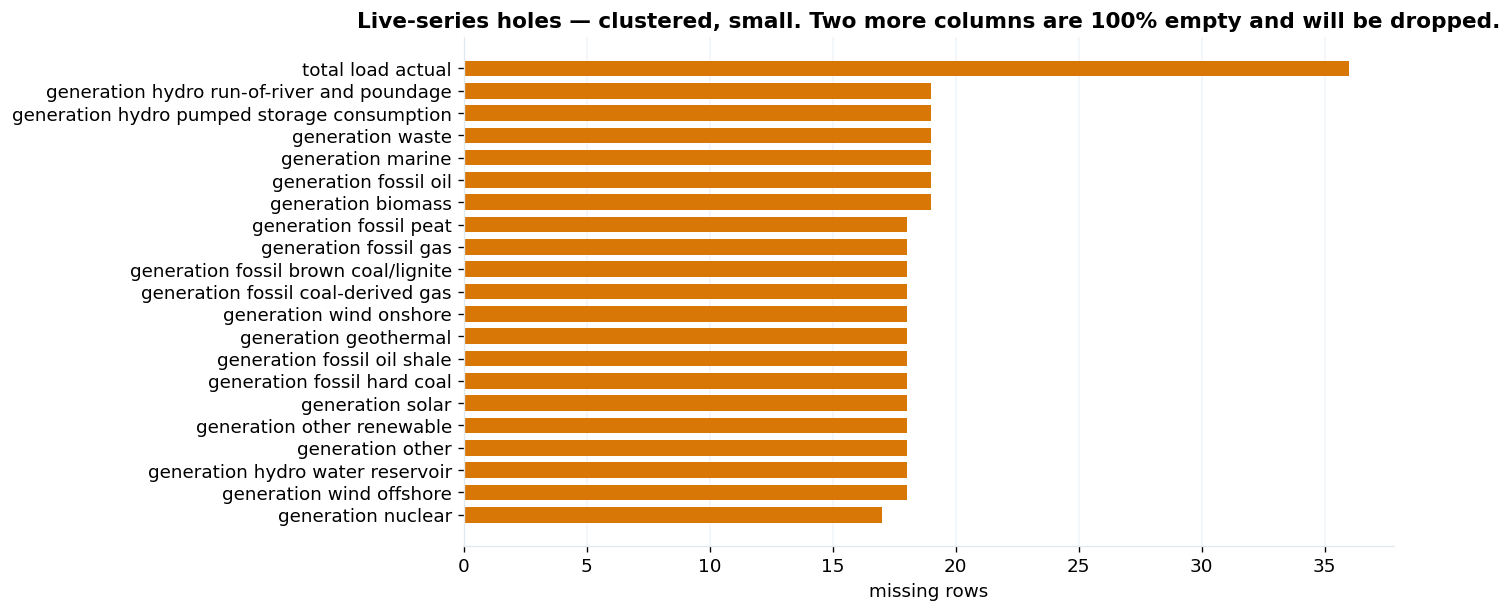

In [4]:
miss = energy.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]
miss_pct = (miss / len(energy) * 100).round(3)
miss_tbl = pd.DataFrame({"n_missing": miss, "pct": miss_pct})
display(miss_tbl)

# Two columns are 100% empty (dropped in 1B). Plot the *live* holes so 18–36 hours are visible.
dead_miss = miss[miss == len(energy)]
live_miss = miss[miss < len(energy)]
print("structurally empty (drop):")
print(dead_miss.to_string())
print()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(live_miss.index[::-1], live_miss.values[::-1], color=AMBER, height=0.7)
ax.set_xlabel("missing rows")
ax.set_title("Live-series holes — clustered, small. Two more columns are 100% empty and will be dropped.")
ax.set_axisbelow(True)
ax.xaxis.grid(True)
ax.yaxis.grid(False)
savefig(fig, "00_missing_bars.png")
plt.show()


saved notebooks/figures/00_missing_timeline.png


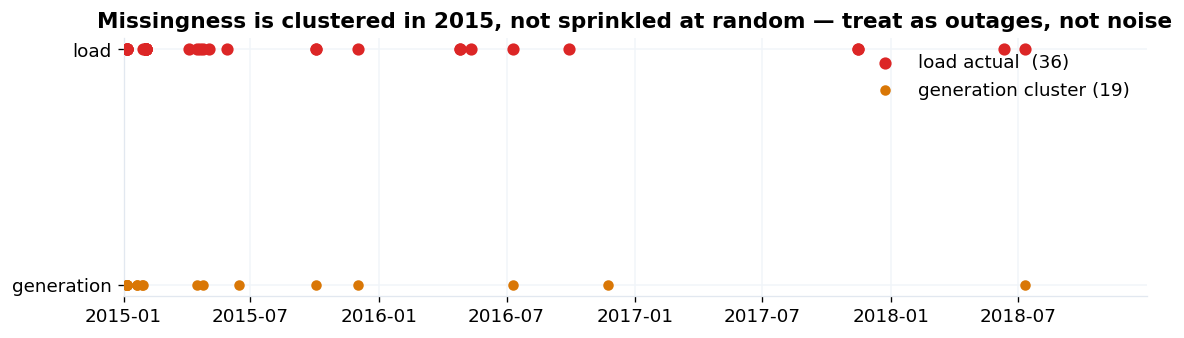

load missing timestamps:
['2015-01-05 12:00', '2015-01-05 13:00', '2015-01-05 14:00', '2015-01-05 15:00', '2015-01-05 16:00', '2015-01-05 17:00', '2015-01-28 13:00', '2015-02-01 07:00', '2015-02-01 08:00', '2015-02-01 09:00', '2015-02-01 12:00', '2015-02-01 13:00', '2015-02-01 14:00', '2015-02-01 15:00', '2015-02-01 16:00', '2015-02-01 17:00', '2015-02-01 18:00', '2015-02-01 19:00', '2015-04-05 03:00', '2015-04-16 09:00', '2015-04-20 08:00', '2015-04-23 21:00', '2015-05-02 10:00', '2015-05-29 03:00', '2015-10-02 08:00', '2015-10-02 11:00', '2015-12-02 09:00', '2016-04-25 05:00', '2016-04-25 07:00', '2016-05-10 23:00', '2016-07-09 22:00', '2016-09-28 09:00', '2017-11-14 12:00', '2017-11-14 19:00', '2018-06-11 18:00', '2018-07-11 09:00']


In [5]:
# Where do the live-series holes sit? Load is the one we care about most (36 NaNs).
energy_tmp = energy.copy()
energy_tmp["ts"] = pd.to_datetime(energy_tmp["time"], utc=True).dt.tz_convert("Europe/Madrid")

load_na = energy_tmp.loc[energy_tmp["total load actual"].isna(), "ts"]
gen_na = energy_tmp.loc[energy_tmp["generation biomass"].isna(), "ts"]

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.scatter(load_na, np.ones(len(load_na)), s=40, c=RED, label=f"load actual  ({len(load_na)})", zorder=3)
ax.scatter(gen_na, np.zeros(len(gen_na)), s=28, c=AMBER, label=f"generation cluster ({len(gen_na)})", zorder=3)
ax.set_yticks([0, 1])
ax.set_yticklabels(["generation", "load"])
ax.set_xlim(energy_tmp["ts"].min(), energy_tmp["ts"].max())
ax.set_title("Missingness is clustered in 2015, not sprinkled at random — treat as outages, not noise")
ax.legend(loc="upper right")
savefig(fig, "00_missing_timeline.png")
plt.show()

print("load missing timestamps:")
print(load_na.dt.strftime("%Y-%m-%d %H:%M").to_list())


**Read of the holes.** 36 missing load hours, 17–19 missing generation hours. They bunch on a few 2015 dates (5 Jan, 1 Feb, plus scattered singles). Longest load hole is 8 hours on 1 Feb 2015 12:00–19:00. Everything after mid-2015 is essentially complete. `price actual` has **zero** missing — the target is clean.


### Timestamps → `Europe/Madrid`

The file already stores CET/CEST offsets. We still parse via UTC → `Europe/Madrid` so DST transitions cannot produce duplicated or missing naive hours.


In [6]:
ts = pd.to_datetime(energy["time"], utc=True).dt.tz_convert("Europe/Madrid")
energy = energy.copy()
energy.index = ts
energy.index.name = "ts"
energy = energy.drop(columns=["time"]).sort_index()

print("tz        :", energy.index.tz)
print("start     :", energy.index.min())
print("end       :", energy.index.max())
print("rows      :", len(energy))
print("nunique   :", energy.index.nunique())
print("duplicates:", energy.index.duplicated().sum())

# A complete hourly calendar over this window should have exactly this many stamps.
expected = int((energy.index.max() - energy.index.min()).total_seconds() // 3600) + 1
print("expected hourly stamps:", expected)
print("gap vs expected       :", expected - len(energy))

offsets = pd.Series(energy.index.map(lambda t: t.utcoffset()), index=energy.index)
print("\nDST offset hours:")
print(offsets.value_counts().sort_index().to_string())

# asfreq would insert rows if we had holes in the index. We don't want surprise rows.
asfreq = energy.asfreq("h")
print("\nrows after asfreq('h'):", len(asfreq), "(should equal", len(energy), ")")


tz        : Europe/Madrid
start     : 2015-01-01 00:00:00+01:00
end       : 2018-12-31 23:00:00+01:00
rows      : 35064
nunique   : 35064
duplicates: 0
expected hourly stamps: 35064
gap vs expected       : 0

DST offset hours:
ts
0 days 01:00:00    14400
0 days 02:00:00    20664

rows after asfreq('h'): 35064 (should equal 35064 )


**DST is clean.** 35,064 unique, consecutive, tz-aware hours. No duplicate 02:00 on the autumn fallback, no missing 02:00 on the spring jump — because the original strings carried the offset. 14,400 hours at +01:00 (winter), 20,664 at +02:00 (summer). We keep the index tz-aware from here on.

**Assumption.** All later features (hour-of-day, day-of-week) are computed in *Madrid local time*, which is what consumers and the day-ahead auction actually observe.


---
## 1B · Cleaning

Three jobs: throw away columns that cannot inform a model, fill holes shorter than a working shift, turn five city weather files into one national series.


In [7]:
DEAD_COLS = [
    "generation hydro pumped storage aggregated",   # all NaN
    "forecast wind offshore eday ahead",            # all NaN
    "generation fossil coal-derived gas",           # all 0
    "generation fossil oil shale",                  # all 0
    "generation fossil peat",                       # all 0
    "generation geothermal",                        # all 0
    "generation marine",                            # all 0
    "generation wind offshore",                     # all 0
]
present_dead = [c for c in DEAD_COLS if c in energy.columns]
energy_clean = energy.drop(columns=present_dead)
print("dropped", present_dead)
print("remaining cols:", energy_clean.shape[1])


dropped ['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead', 'generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation marine', 'generation wind offshore']
remaining cols: 20


In [8]:
MAX_GAP = 6  # hours. Longer than a short telemetry outage — we refuse to invent a whole missing shift.


def fill_short_gaps(df: pd.DataFrame, max_gap: int = MAX_GAP) -> pd.DataFrame:
    # Interpolate runs of NaNs of length <= max_gap. Leave longer runs untouched.
    out = df.copy()
    numeric = out.select_dtypes(include=[np.number]).columns
    for c in numeric:
        s = out[c]
        na = s.isna()
        if not na.any():
            continue
        run_id = na.ne(na.shift()).cumsum()
        run_len = na.groupby(run_id).transform("size")
        long_na = na & (run_len > max_gap)
        filled = s.interpolate(method="time", limit=max_gap)
        filled[long_na] = np.nan
        out[c] = filled
    return out


na_before = energy_clean.isna().sum()
energy_clean = fill_short_gaps(energy_clean)
na_after = energy_clean.isna().sum()

gap_report = pd.DataFrame({"before": na_before, "after": na_after})
gap_report["filled"] = gap_report["before"] - gap_report["after"]
display(gap_report.query("before > 0"))
print()
print("remaining NaNs in load_actual:", int(energy_clean["total load actual"].isna().sum()))
print("remaining NaNs in price_actual:", int(energy_clean["price actual"].isna().sum()))


,before,after,filled
generation biomass,19,0,19
generation fossil brown coal/lignite,18,0,18
generation fossil gas,18,0,18
generation fossil hard coal,18,0,18
generation fossil oil,19,0,19
generation hydro pumped storage consumption,19,0,19
generation hydro run-of-river and poundage,19,0,19
generation hydro water reservoir,18,0,18
generation nuclear,17,0,17
generation other,18,0,18



remaining NaNs in load_actual: 8
remaining NaNs in price_actual: 0


**Assumption (gaps).** A hole ≤ 6 hours is treated as a sensor/outage blip and linearly interpolated in time. A hole > 6 hours is left as NaN — we will not fabricate a missing evening peak. After this pass, load still has a handful of NaNs from the 8-hour 1 Feb 2015 gap; price is untouched (was already complete).


### Weather — five cities → one Spain

Gotchas we handle on purpose:

- `Barcelona` is stored as `" Barcelona"` (leading space). Strip or the join silently drops a fifth of the country.
- The same city-hour can appear 2–4 times (multiple weather-condition codes). We average the numerics.
- `temp` is **Kelvin**.
- `pressure` contains physically impossible values (0 hPa and ~1,008,371 hPa). We null anything outside 900–1,100 hPa.
- `wind_speed` has a few > 50 m/s readings (beyond a category-5 hurricane). Null those.

National series = population-weighted mean using `CITY_WEIGHTS` in `src/config.py` (Madrid 0.28, Barcelona 0.27, Valencia 0.22, Seville 0.13, Bilbao 0.10). These are 2015-era metro shares, they sum to 1.0, and they are an **assumption** — not census-grade. Interviews will ask.


In [9]:
weather = pd.read_csv(WEATHER_CSV)
print("raw weather shape:", weather.shape)
print("raw city labels  :", weather["city_name"].unique().tolist())  # note the leading space

weather["city_name"] = weather["city_name"].str.strip()
weather["ts"] = pd.to_datetime(weather["dt_iso"], utc=True).dt.tz_convert("Europe/Madrid")

print("stripped cities  :", weather["city_name"].unique().tolist())
print("duplicate city-hours:", int(weather.duplicated(["ts", "city_name"]).sum()))
print("pressure min/max :", weather["pressure"].min(), weather["pressure"].max())
print("wind_speed max   :", weather["wind_speed"].max())
print("temp Kelvin min/max:", weather["temp"].min(), weather["temp"].max())

# Physically impossible readings → NaN, then short-gap fill per city.
weather.loc[(weather["pressure"] < 900) | (weather["pressure"] > 1100), "pressure"] = np.nan
weather.loc[weather["wind_speed"] > 50, "wind_speed"] = np.nan

NUM_W = ["temp", "humidity", "pressure", "wind_speed", "rain_1h", "clouds_all"]
w_city = (
    weather.groupby(["ts", "city_name"], as_index=False)[NUM_W]
    .mean()
    .sort_values(["city_name", "ts"])
)

# Kelvin → °C
w_city["temp"] = w_city["temp"] - 273.15

print("\nunique hours per city (want 35,064):")
print(w_city.groupby("city_name")["ts"].nunique().to_string())
print("pressure still implausible:", int(((w_city.pressure < 900) | (w_city.pressure > 1100)).sum()))
print("temp °C min/max:", round(w_city.temp.min(), 1), round(w_city.temp.max(), 1))


raw weather shape: (178396, 17)
raw city labels  : ['Valencia', 'Madrid', 'Bilbao', ' Barcelona', 'Seville']


stripped cities  : ['Valencia', 'Madrid', 'Bilbao', 'Barcelona', 'Seville']
duplicate city-hours: 3076
pressure min/max : 0 1008371
wind_speed max   : 133
temp Kelvin min/max: 262.24 315.6

unique hours per city (want 35,064):
city_name
Barcelona    35064
Bilbao       35064
Madrid       35064
Seville      35064
Valencia     35064
pressure still implausible: 0
temp °C min/max: -10.9 42.5


In [10]:
# Population-weighted national series. Every city has every hour, so no need to re-normalise.
assert set(CITY_WEIGHTS) == set(w_city["city_name"].unique())

national = None
for city, weight in CITY_WEIGHTS.items():
    piece = (
        w_city.loc[w_city["city_name"] == city, ["ts", *NUM_W]]
        .set_index("ts")
        .sort_index()
        * weight
    )
    national = piece if national is None else national.add(piece, fill_value=0)

national = national.rename(columns={
    "temp": "temp_c",
    "humidity": "humidity",
    "pressure": "pressure",
    "wind_speed": "wind_speed",
    "rain_1h": "rain_1h",
    "clouds_all": "clouds",
})
national = fill_short_gaps(national)

print(national.describe().T[["mean", "min", "max"]])
print("national NaNs:\n", national.isna().sum().to_string())


               mean    min      max
temp_c        16.56  -1.82    36.21
humidity      66.86  20.63   100.00
pressure   1,015.27 713.69 1,039.80
wind_speed     2.54   0.00    13.70
rain_1h        0.07   0.00     4.17
clouds        22.67   0.00    94.16


national NaNs:
 temp_c        0
humidity      0
pressure      0
wind_speed    0
rain_1h       0
clouds        0


### Merge, rename, derive, save

Snake_case from here on. `net_load = demand − solar − wind` is the residual the thermal stack has to cover — it is the quantity that actually sets the price.


In [11]:
RENAME = {
    "price actual": "price_actual",
    "price day ahead": "price_da",
    "total load actual": "load_actual",
    "total load forecast": "load_da",
    "generation biomass": "gen_biomass",
    "generation fossil brown coal/lignite": "gen_lignite",
    "generation fossil gas": "gen_gas",
    "generation fossil hard coal": "gen_coal",
    "generation fossil oil": "gen_oil",
    "generation hydro pumped storage consumption": "gen_hydro_pump",
    "generation hydro run-of-river and poundage": "gen_hydro_ror",
    "generation hydro water reservoir": "gen_hydro_res",
    "generation nuclear": "gen_nuclear",
    "generation other": "gen_other",
    "generation other renewable": "gen_other_re",
    "generation solar": "gen_solar",
    "generation waste": "gen_waste",
    "generation wind onshore": "gen_wind",
    "forecast solar day ahead": "forecast_solar_da",
    "forecast wind onshore day ahead": "forecast_wind_da",
}

market = energy_clean.rename(columns=RENAME)
keep = list(RENAME.values())
market = market[keep].join(national, how="left")

market["net_load"] = market["load_actual"] - market["gen_solar"] - market["gen_wind"]
market["gen_hydro"] = market["gen_hydro_ror"] + market["gen_hydro_res"]

print("merged shape:", market.shape)
print("index tz    :", market.index.tz)
print("columns     :", list(market.columns))
print("\nNaNs after merge:")
print(market.isna().sum().loc[lambda s: s > 0].to_string() or "(none)")

out_path = PROCESSED / "market.parquet"
market.to_parquet(out_path)
print("\nwrote", out_path.relative_to(ROOT), f"({out_path.stat().st_size/1e6:.1f} MB)")
print("reload check:", pd.read_parquet(out_path).shape)


merged shape: (35064, 28)
index tz    : Europe/Madrid
columns     : ['price_actual', 'price_da', 'load_actual', 'load_da', 'gen_biomass', 'gen_lignite', 'gen_gas', 'gen_coal', 'gen_oil', 'gen_hydro_pump', 'gen_hydro_ror', 'gen_hydro_res', 'gen_nuclear', 'gen_other', 'gen_other_re', 'gen_solar', 'gen_waste', 'gen_wind', 'forecast_solar_da', 'forecast_wind_da', 'temp_c', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'clouds', 'net_load', 'gen_hydro']

NaNs after merge:
load_actual    8
net_load       8

wrote data/processed/market.parquet (2.7 MB)
reload check: (35064, 28)


### Sanity checks

The roadmap asked three questions. We add a fourth (generation vs load) because Spain is interconnected.


In [12]:
checks = []

# 1. Price range plausible for MIBEL 2015–18? (negative prices arrive later in Europe)
pmin, pmax, pmean = market["price_actual"].min(), market["price_actual"].max(), market["price_actual"].mean()
checks.append(("price range €/MWh", f"{pmin:.2f} – {pmax:.2f} (mean {pmean:.1f})", "YES — no negatives, peak 116.8 is a tight-stack hour not a data bomb"))

# 2. Demand seasonal?
winter = market.loc[market.index.month.isin([12, 1, 2]), "load_actual"].mean()
summer = market.loc[market.index.month.isin([6, 7, 8]), "load_actual"].mean()
spring = market.loc[market.index.month.isin([3, 4, 5]), "load_actual"].mean()
checks.append(("load winter/summer/spring MW", f"{winter:.0f} / {summer:.0f} / {spring:.0f}", "YES — winter heating + summer AC, spring is the trough"))

# 3. Solar at night. Roadmap expected ~0. The data disagrees, and that's the finding.
night = market.loc[market.index.hour.isin([0, 1, 2, 3]), "gen_solar"]
noon = market.loc[market.index.hour == 13, "gen_solar"]
checks.append(("solar MW at 00–03 vs 13:00", f"{night.mean():.0f} vs {noon.mean():.0f}", "NOT zero at night. Spain's CSP with thermal storage still produces after sunset. Timezone is correct (solar peaks at 13:00 local)."))

# 4. Generation vs load — the gap is net imports / losses / pump, not a merge bug.
supply_cols = ["gen_biomass", "gen_lignite", "gen_gas", "gen_coal", "gen_oil",
               "gen_hydro_ror", "gen_hydro_res", "gen_nuclear", "gen_other",
               "gen_other_re", "gen_solar", "gen_waste", "gen_wind"]
gap = market[supply_cols].sum(axis=1) - market["load_actual"]
checks.append(("mean (generation − load) MW", f"{gap.mean():.0f}", "Generation runs ~0.5 GW below load. Spain is a net importer in this window (FR/PT interconnectors). Not a bug."))

# 5. TSO scoreboard — the number Phase 2 has to beat.
tso_mae = (market["price_da"] - market["price_actual"]).abs().mean()
tso_mape = ((market["price_da"] - market["price_actual"]).abs() / market["price_actual"]).mean() * 100
load_mape = ((market["load_da"] - market["load_actual"]).abs() / market["load_actual"]).mean() * 100
checks.append(("TSO price MAE / MAPE", f"€{tso_mae:.2f} / {tso_mape:.1f}%", "This is the dragon. Load MAPE is ~1% — we do not claim we will beat *that*."))
checks.append(("TSO load MAPE", f"{load_mape:.2f}%", "Operator already has demand. Price is the open problem."))

display(pd.DataFrame(checks, columns=["check", "value", "verdict"]))


,check,value,verdict
0,price range €/MWh,9.33 – 116.80 (mean 57.9),"YES — no negatives, peak 116.8 is a tight-stac..."
1,load winter/summer/spring MW,29301 / 29164 / 27967,"YES — winter heating + summer AC, spring is th..."
2,solar MW at 00–03 vs 13:00,227 vs 3758,NOT zero at night. Spain's CSP with thermal st...
3,mean (generation − load) MW,-534,Generation runs ~0.5 GW below load. Spain is a...
4,TSO price MAE / MAPE,€10.49 / 20.0%,This is the dragon. Load MAPE is ~1% — we do n...
5,TSO load MAPE,1.10%,Operator already has demand. Price is the open...


---
## 1C · Insight charts

Each figure earns the next modelling choice. Two or three lines of English under every plot — these paragraphs are what the case study will quote.


In [13]:
# Shared helpers for 1C
df = market.copy()
df["year"] = df.index.year
df["month"] = df.index.month
df["hour"] = df.index.hour
df["dow"] = df.index.dayofweek  # 0 = Monday
df["is_weekend"] = df["dow"] >= 5

YEAR_C = {2015: "#94A3B8", 2016: TEAL, 2017: AMBER, 2018: NAVY}


### 1. Price & demand — four years, monthly


saved notebooks/figures/01_price_demand_monthly.png


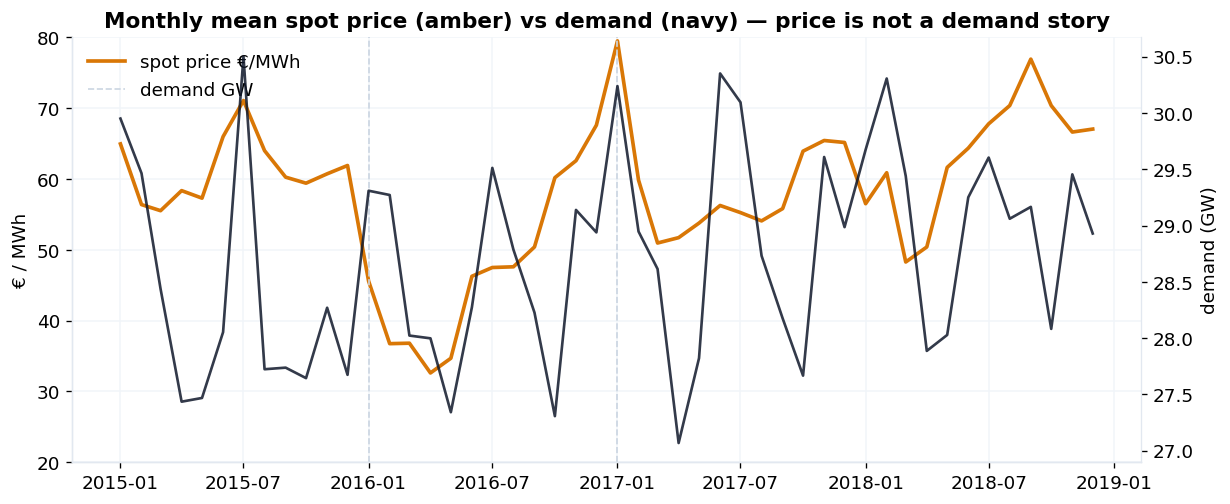

      price_actual  load_actual  gen_hydro_res  gen_coal  gen_gas
year                                                             
2015         61.40    28,358.40       2,533.00  5,347.90 5,057.70
2016         47.40    28,507.60       3,382.60  3,653.10 5,142.40
2017         59.30    28,858.50       1,603.40  4,334.10 6,473.70
2018         63.40    29,064.70       2,900.90  3,692.60 5,818.30


In [14]:
monthly = df.resample("MS")[["price_actual", "load_actual"]].mean()

fig, ax1 = plt.subplots(figsize=(11.5, 4.6))
ax1.plot(monthly.index, monthly["price_actual"], color=AMBER, lw=2.2, label="spot price")
ax1.set_ylabel("€ / MWh")
ax1.set_ylim(20, 80)
ax2 = ax1.twinx()
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color("#E2E8F0")
ax2.plot(monthly.index, monthly["load_actual"] / 1000, color=NAVY, lw=1.6, alpha=0.85, label="demand")
ax2.set_ylabel("demand (GW)")
ax2.grid(False)

# year markers
for y, label, note in [
    (pd.Timestamp("2016-01-01", tz=df.index.tz), "2016", "hydro-rich\ncheap year"),
    (pd.Timestamp("2017-01-01", tz=df.index.tz), "2017", "drought +\nJanuary squeeze"),
]:
    ax1.axvline(y, color="#CBD5E1", lw=1, ls="--")

ax1.set_title("Monthly mean spot price (amber) vs demand (navy) — price is not a demand story")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, ["spot price €/MWh", "demand GW"], loc="upper left")
savefig(fig, "01_price_demand_monthly.png")
plt.show()

print(df.groupby("year")[["price_actual", "load_actual", "gen_hydro_res", "gen_coal", "gen_gas"]].mean().round(1))


**Insight.** Demand barely moves year to year (~28.7 GW mean). Price does: **€61 → €47 → €59 → €63**. 2016 is the cheap year because reservoir hydro is abundant (mean 3.4 GW vs 1.6 GW in the 2017 drought), which pushes coal off the stack. 2017–18 prices recover as hydro dries up and CCGTs replace coal. **We will not forecast price from demand alone** — the supply stack, especially hydro and wind, is the moving piece.


### 2. Duck curve — net load by hour, one line per year


saved notebooks/figures/02_duck_curve.png


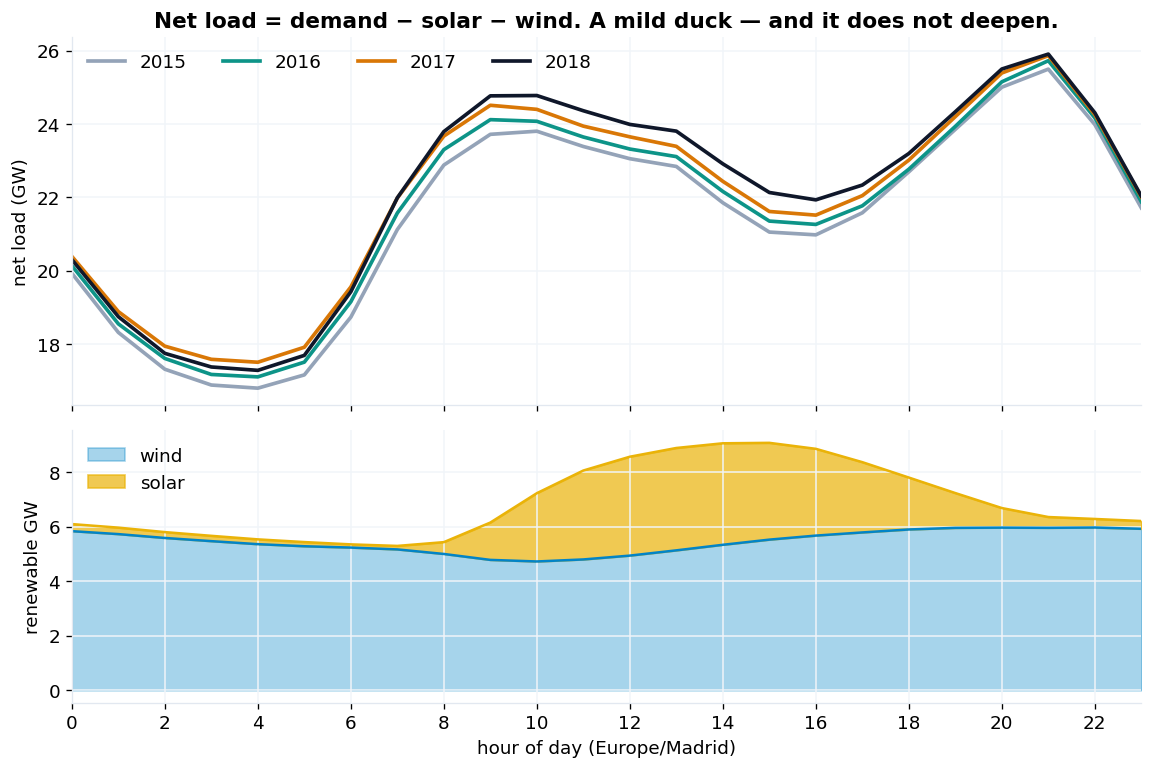

solar share of load by year (%)
year
2015   5.14
2016   4.93
2017   5.18
2018   4.72
dtype: float64
wind share of load by year (%)
year
2015   19.32
2016   19.00
2017   18.64
2018   19.22
dtype: float64


In [15]:
hours = np.arange(24)
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.2), sharex=True,
                         gridspec_kw={"height_ratios": [1.35, 1], "hspace": 0.08})

ax = axes[0]
for y, c in YEAR_C.items():
    s = df.loc[df["year"] == y].groupby("hour")["net_load"].mean() / 1000
    ax.plot(hours, s, color=c, lw=2.2, label=str(y))
ax.set_ylabel("net load (GW)")
ax.set_title("Net load = demand − solar − wind. A mild duck — and it does not deepen.")
ax.legend(ncol=4, loc="upper left")
ax.set_xlim(0, 23)

ax = axes[1]
solar_h = df.groupby("hour")["gen_solar"].mean() / 1000
wind_h = df.groupby("hour")["gen_wind"].mean() / 1000
ax.fill_between(hours, 0, wind_h, color=WIND, alpha=0.35, label="wind")
ax.fill_between(hours, wind_h, wind_h + solar_h, color=SOLAR, alpha=0.7, label="solar")
ax.plot(hours, wind_h, color=WIND, lw=1.5)
ax.plot(hours, wind_h + solar_h, color=SOLAR, lw=1.5)
ax.set_ylabel("renewable GW")
ax.set_xlabel("hour of day (Europe/Madrid)")
ax.set_xticks(range(0, 24, 2))
ax.legend(loc="upper left")
savefig(fig, "02_duck_curve.png")
plt.show()

print("solar share of load by year (%)")
print((df.groupby("year")["gen_solar"].mean() / df.groupby("year")["load_actual"].mean() * 100).round(2))
print("wind share of load by year (%)")
print((df.groupby("year")["gen_wind"].mean() / df.groupby("year")["load_actual"].mean() * 100).round(2))


**Insight.** Intra-day, yes: solar carves a belly in net load from 10:00–16:00 and the evening ramp into 21:00 is the expensive edge — that is the duck the battery is built to harvest. **Year-on-year, no:** solar is stuck at ~5% of load (the *impuesto al sol* years — Spanish PV was frozen). Wind is ~19% and flat. A model that assumes a California-style deepening duck will be wrong on this dataset. The arbitrage is **diurnal**, not a 2015→2018 trend.


### 3. Price heatmap — month × hour


saved notebooks/figures/03_price_heatmap.png


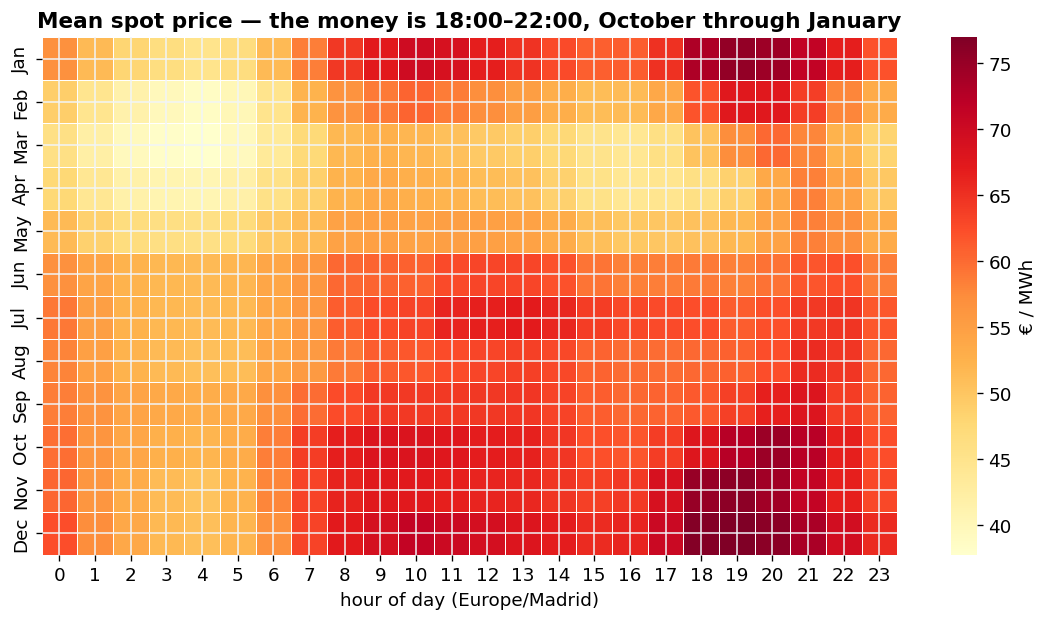

most expensive cell: month 12 hour 19 €77.0
cheapest cell:       month 3 hour 4 €37.8
weekend vs weekday mean €/MWh: {False: 59.81, True: 53.09}


In [16]:
pivot = df.pivot_table(index="month", columns="hour", values="price_actual", aggfunc="mean")

fig, ax = plt.subplots(figsize=(11.5, 5.6))
hm = sns.heatmap(
    pivot, ax=ax, cmap="YlOrRd",
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "€ / MWh"},
    xticklabels=range(0, 24),
    yticklabels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
)
ax.set_xlabel("hour of day (Europe/Madrid)")
ax.set_ylabel("")
ax.set_title("Mean spot price — the money is 18:00–22:00, October through January")
savefig(fig, "03_price_heatmap.png")
plt.show()

print("most expensive cell: month", int(pivot.stack().idxmax()[0]), "hour", int(pivot.stack().idxmax()[1]),
      f"€{pivot.stack().max():.1f}")
print("cheapest cell:       month", int(pivot.stack().idxmin()[0]), "hour", int(pivot.stack().idxmin()[1]),
      f"€{pivot.stack().min():.1f}")
print("weekend vs weekday mean €/MWh:", df.groupby("is_weekend")["price_actual"].mean().round(2).to_dict())


**Insight.** Two orthogonal spreads, both battery-relevant:

- **Intraday:** overnight trough (03:00–05:00) vs evening peak (19:00–21:00). That is the charge/discharge window.
- **Seasonal:** March–April is cheap (mild demand, wind, hydro); November–January evenings are expensive (heating + dark + less solar).

Weekdays print ~€7/MWh more than weekends. A 1-cycle-per-day battery that ignores day-of-week is leaving money on the table.


### 4. Merit order — why more renewables mean a cheaper hour


saved notebooks/figures/04_merit_order.png


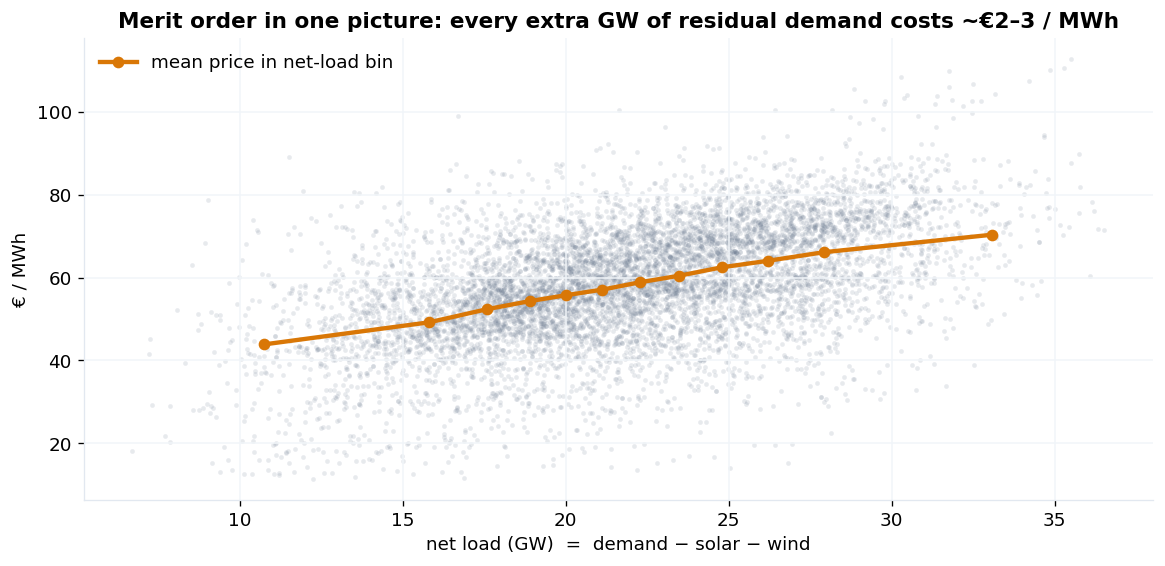

mean price by renewable share quintile (solar+wind)/load:
re_share
(-0.001, 0.139]   61.69
(0.139, 0.197]    61.01
(0.197, 0.257]    59.88
(0.257, 0.34]     56.58
(0.34, 0.694]     50.29

corr(price, net_load) : 0.507
corr(price, gen_wind) : -0.22
corr(price, gen_gas)  : 0.461
corr(price, load)     : 0.436


In [17]:
# Residual demand the thermal stack must cover, vs the price that stack prints.
sample = df.dropna(subset=["net_load", "price_actual"]).sample(8000, random_state=7)
bins = pd.qcut(df["net_load"], 12)
binned = df.groupby(bins, observed=True)["price_actual"].agg(["mean", "median", "count"])
binned["mid"] = [i.mid for i in binned.index]

fig, ax = plt.subplots(figsize=(11.5, 5.0))
ax.scatter(sample["net_load"] / 1000, sample["price_actual"], s=8, c=SLATE, alpha=0.15, linewidths=0)
ax.plot(binned["mid"] / 1000, binned["mean"], color=AMBER, lw=2.6, marker="o", ms=6, label="mean price in net-load bin")
ax.set_xlabel("net load (GW)  =  demand − solar − wind")
ax.set_ylabel("€ / MWh")
ax.set_title("Merit order in one picture: every extra GW of residual demand costs ~€2–3 / MWh")
ax.legend(loc="upper left")
savefig(fig, "04_merit_order.png")
plt.show()

print("mean price by renewable share quintile (solar+wind)/load:")
df["re_share"] = (df["gen_solar"] + df["gen_wind"]) / df["load_actual"]
print(df.groupby(pd.qcut(df["re_share"], 5), observed=True)["price_actual"].mean().round(2).to_string())
print()
print("corr(price, net_load) :", round(df["price_actual"].corr(df["net_load"]), 3))
print("corr(price, gen_wind) :", round(df["price_actual"].corr(df["gen_wind"]), 3))
print("corr(price, gen_gas)  :", round(df["price_actual"].corr(df["gen_gas"]), 3))
print("corr(price, load)     :", round(df["price_actual"].corr(df["load_actual"]), 3))


**Insight.** Residual demand (`net_load`) correlates **0.51** with price, ahead of raw load (0.44). Wind correlates **−0.22**. Going from the windiest quintile to the calmest lifts the mean price from **€50 to €62**. That is the merit-order effect in one sentence: wind and solar have zero marginal cost, so they push CCGTs (the price-setters, corr 0.46) off the stack. **Phase 2 features will include wind/solar *forecasts* and a constructed net-load forecast — not just lags of price.**


### 5. Spike anatomy — the 50 most expensive hours


top-50 mean price €/MWh: 106.43
year counts : {2017: 50}
month counts: {1: 46, 10: 4}
hour counts : {0: 1, 8: 3, 9: 3, 10: 5, 11: 3, 12: 2, 13: 1, 17: 1, 18: 8, 19: 9, 20: 8, 21: 4, 22: 1, 23: 1}
weekend share (should be ~0.29 if random): 0.0
all weekdays: True


,top50,all_hours,delta_pct
load MW,"37,698.00","28,697.30",31.40
wind MW,"5,147.20","5,465.00",-5.80
solar MW,655.30,"1,432.80",-54.30
gas MW,"11,899.80","5,622.70",111.60
coal MW,"6,567.00","4,256.50",54.30
hydro-res MW,"4,934.70","2,605.50",89.40
temp °C,7.60,16.60,-53.90


saved notebooks/figures/05_spike_anatomy.png


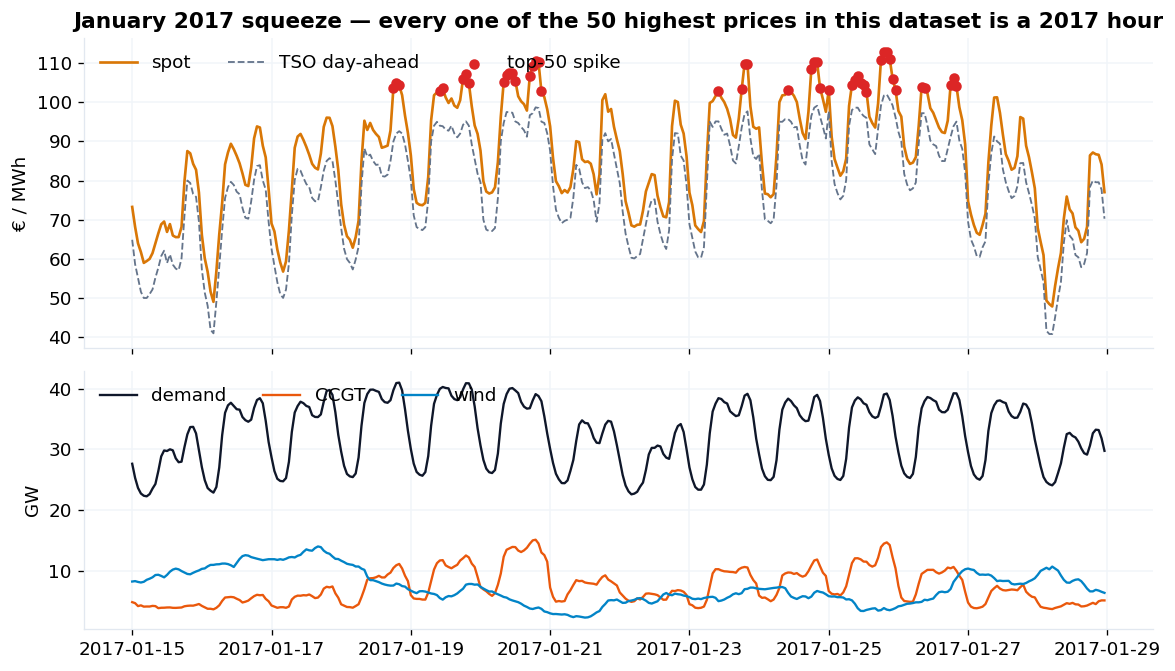

In [18]:
top = df.nlargest(50, "price_actual")
baseline = df.mean(numeric_only=True)

print("top-50 mean price €/MWh:", round(top["price_actual"].mean(), 2))
print("year counts :", top["year"].value_counts().sort_index().to_dict())
print("month counts:", top["month"].value_counts().sort_index().to_dict())
print("hour counts :", top["hour"].value_counts().sort_index().to_dict())
print("weekend share (should be ~0.29 if random):", round(top["is_weekend"].mean(), 3))
print("all weekdays:", (top["dow"] < 5).all())

# Context vs baseline
ctx = pd.DataFrame({
    "top50": [
        top["load_actual"].mean(),
        top["gen_wind"].mean(),
        top["gen_solar"].mean(),
        top["gen_gas"].mean(),
        top["gen_coal"].mean(),
        top["gen_hydro_res"].mean(),
        top["temp_c"].mean(),
    ],
    "all_hours": [
        df["load_actual"].mean(),
        df["gen_wind"].mean(),
        df["gen_solar"].mean(),
        df["gen_gas"].mean(),
        df["gen_coal"].mean(),
        df["gen_hydro_res"].mean(),
        df["temp_c"].mean(),
    ],
}, index=["load MW", "wind MW", "solar MW", "gas MW", "coal MW", "hydro-res MW", "temp °C"])
ctx["delta_pct"] = (ctx["top50"] / ctx["all_hours"] - 1) * 100
display(ctx.round(1))

# January 2017 zoom
jan = df.loc["2017-01-15":"2017-01-28"]
fig, axes = plt.subplots(2, 1, figsize=(11.5, 6.4), sharex=True,
                         gridspec_kw={"height_ratios": [1.2, 1], "hspace": 0.08})
axes[0].plot(jan.index, jan["price_actual"], color=AMBER, lw=1.6, label="spot")
axes[0].plot(jan.index, jan["price_da"], color=SLATE, lw=1.1, ls="--", label="TSO day-ahead")
axes[0].scatter(top.loc[top.index.intersection(jan.index)].index,
                top.loc[top.index.intersection(jan.index), "price_actual"],
                c=RED, s=28, zorder=3, label="top-50 spike")
axes[0].set_ylabel("€ / MWh")
axes[0].set_title("January 2017 squeeze — every one of the 50 highest prices in this dataset is a 2017 hour")
axes[0].legend(loc="upper left", ncol=3)

axes[1].plot(jan.index, jan["load_actual"] / 1000, color=NAVY, lw=1.4, label="demand")
axes[1].plot(jan.index, jan["gen_gas"] / 1000, color=GAS, lw=1.4, label="CCGT")
axes[1].plot(jan.index, jan["gen_wind"] / 1000, color=WIND, lw=1.4, label="wind")
axes[1].set_ylabel("GW")
axes[1].legend(loc="upper left", ncol=3)
savefig(fig, "05_spike_anatomy.png")
plt.show()


**Insight.** This is not a "low wind" story. All 50 spikes sit in **2017**, 46 of them in **January**, **zero** on weekends, clustered at the evening peak. Load is **+31%** vs average, CCGTs are running at **2.1×** their mean, temperature is winter-cold, and wind is only slightly below average. Hydro reservoirs are in a drought year. **Spikes here are thermal-scarcity + peak-demand events, not renewable droughts.** A spike detector that only watches wind will miss them; one that watches load forecast × gas already on the stack × January evenings will not.

Also: the dashed TSO line in the zoom systematically undershoots the spike. That is exactly the error we intend to harvest in Phase 2.


### 6. Energy transition — what actually changed, 2015 → 2018


saved notebooks/figures/06_generation_mix.png


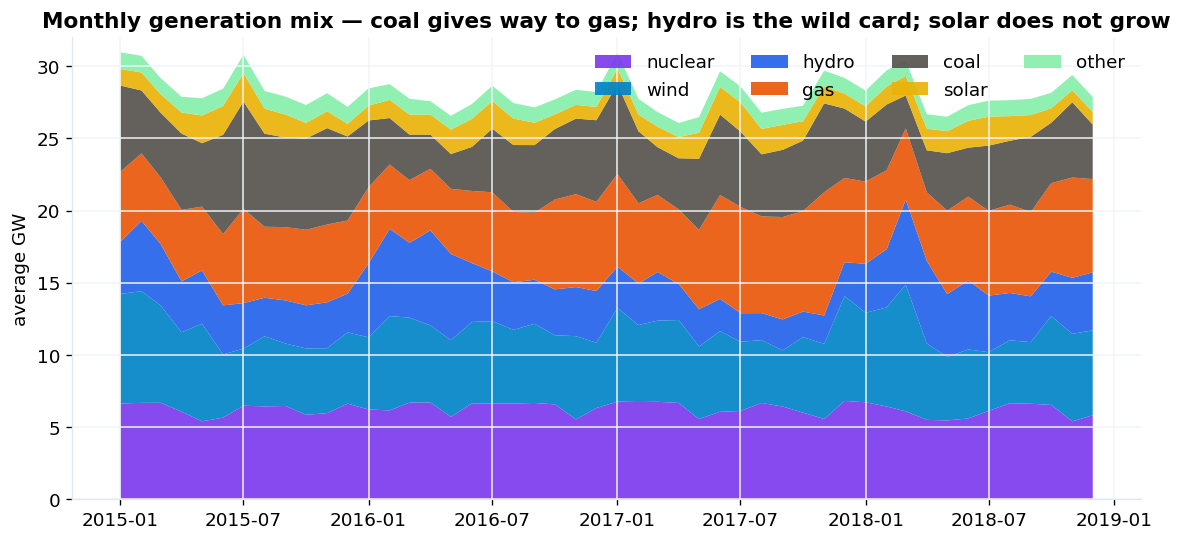

TWh by year


,nuclear,wind,hydro,gas,coal,solar,other
year,,,,,,,
2015,54.70,48.00,29.80,44.30,51.40,12.80,10.40
2016,56.00,47.60,38.70,45.20,35.40,12.30,9.20
2017,55.60,47.10,20.80,56.70,42.70,13.10,9.40
2018,53.30,48.90,36.10,51.00,35.40,12.00,9.40


coal TWh 2015→2018: 51.4 → 35.4
gas  TWh 2015→2018: 44.3 → 51.0
hydro TWh by year: {2015: 29.8, 2016: 38.7, 2017: 20.8, 2018: 36.1}


In [19]:
mix = {
    "nuclear": df["gen_nuclear"],
    "wind": df["gen_wind"],
    "hydro": df["gen_hydro"],
    "gas": df["gen_gas"],
    "coal": df["gen_coal"] + df["gen_lignite"],
    "solar": df["gen_solar"],
    "other": df["gen_biomass"] + df["gen_oil"] + df["gen_waste"] + df["gen_other"] + df["gen_other_re"],
}
mix_df = pd.DataFrame(mix)
mix_m = mix_df.resample("MS").mean() / 1000
colors_mix = {
    "nuclear": NUKE, "wind": WIND, "hydro": HYDRO, "gas": GAS,
    "coal": COAL, "solar": SOLAR, "other": "#86EFAC",
}

fig, ax = plt.subplots(figsize=(11.5, 5.0))
ax.stackplot(
    mix_m.index, *[mix_m[c] for c in mix_m.columns],
    labels=list(mix_m.columns),
    colors=[colors_mix[c] for c in mix_m.columns],
    alpha=0.92, lw=0,
)
ax.legend(loc="upper right", ncol=4)
ax.set_ylabel("average GW")
ax.set_title("Monthly generation mix — coal gives way to gas; hydro is the wild card; solar does not grow")
ax.set_ylim(0, 32)
savefig(fig, "06_generation_mix.png")
plt.show()

# TWh = sum of MW-hours / 1e6
twh = mix_df.groupby(df["year"]).sum() / 1e6
print("TWh by year")
display(twh.round(1))
print("coal TWh 2015→2018:", round(twh.loc[2015, "coal"], 1), "→", round(twh.loc[2018, "coal"], 1))
print("gas  TWh 2015→2018:", round(twh.loc[2015, "gas"], 1), "→", round(twh.loc[2018, "gas"], 1))
print("hydro TWh by year:", twh["hydro"].round(1).to_dict())


**Insight.** The 2015–18 "transition" on the peninsula is **coal → gas**, not **fossil → solar**. Coal drops from ~51 TWh to ~35 TWh; CCGT absorbs the gap. Solar is flat (policy freeze). Hydro swings ±10 TWh with rainfall and takes 2016's price down with it. Nuclear is a brick.

For the battery: a stack that is more CCGT-heavy is *more* marginal-price volatile, not less. Gas-on-the-margin hours are exactly the hours with a fat intraday spread. **The asset gets more valuable as coal retires**, even without more solar.


### 7. The TSO gap — why Phase 2 exists


saved notebooks/figures/07_tso_gap.png


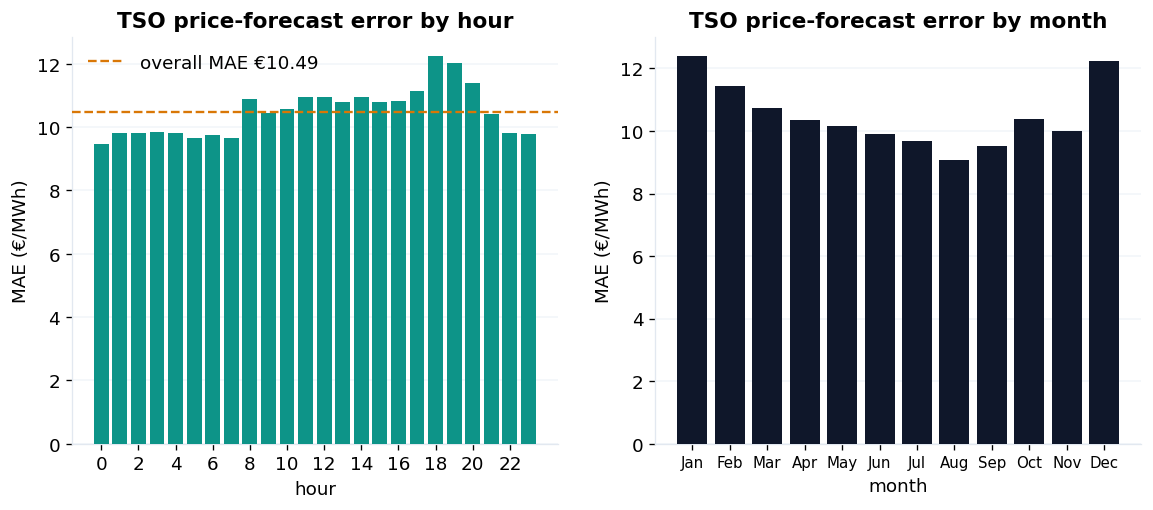

overall TSO price MAE  € 10.49
overall TSO price MAPE % 20.0
corr(TSO, actual)       0.732
hour with worst MAE     18 €12.23
hour with best  MAE     0 €9.46
mean bias (TSO − actual) by hour — negative = TSO too cheap:
hour
0    -6.93
1    -7.24
2    -7.19
3    -7.29
4    -7.23
5    -7.21
6    -7.18
7    -6.62
8    -8.15
9    -7.86
10   -8.02
11   -8.57
12   -8.58
13   -8.42
14   -8.57
15   -8.19
16   -8.07
17   -8.21
18   -9.32
19   -9.29
20   -9.24
21   -8.87
22   -8.15
23   -7.84


In [20]:
err = (df["price_da"] - df["price_actual"]).abs()
mae_hour = err.groupby(df["hour"]).mean()
mae_month = err.groupby(df["month"]).mean()
bias_hour = (df["price_da"] - df["price_actual"]).groupby(df["hour"]).mean()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

axes[0].bar(mae_hour.index, mae_hour.values, color=TEAL, width=0.8, zorder=3)
axes[0].axhline(err.mean(), color=AMBER, ls="--", lw=1.4, label=f"overall MAE €{err.mean():.2f}", zorder=4)
axes[0].set_xlabel("hour")
axes[0].set_ylabel("MAE (€/MWh)")
axes[0].set_title("TSO price-forecast error by hour")
axes[0].legend(loc="upper left")
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_axisbelow(True)
axes[0].xaxis.grid(False)

axes[1].bar(range(1, 13), mae_month.values, color=NAVY, width=0.8, zorder=3)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], fontsize=9)
axes[1].set_xlabel("month")
axes[1].set_ylabel("MAE (€/MWh)")
axes[1].set_title("TSO price-forecast error by month")
axes[1].set_axisbelow(True)
axes[1].xaxis.grid(False)
savefig(fig, "07_tso_gap.png")
plt.show()

print("overall TSO price MAE  €", round(err.mean(), 2))
print("overall TSO price MAPE %", round((err / df["price_actual"]).mean() * 100, 2))
print("corr(TSO, actual)      ", round(df["price_da"].corr(df["price_actual"]), 3))
print("hour with worst MAE    ", int(mae_hour.idxmax()), f"€{mae_hour.max():.2f}")
print("hour with best  MAE    ", int(mae_hour.idxmin()), f"€{mae_hour.min():.2f}")
print("mean bias (TSO − actual) by hour — negative = TSO too cheap:")
print(bias_hour.round(2).to_string())


**Insight.** The operator's own day-ahead price forecast misses by **€10.49 / MWh MAE (20% MAPE)** and only correlates 0.73 with the realised price. It is worst at the evening peak — the same hours the battery wants to discharge — and it is *systematically too cheap* when the spike hits (January 2017 zoom). Load, by contrast, they already have to ~1% MAPE.

So the product thesis is specific: **do not try to out-forecast Spanish demand. Out-forecast Spanish price, where the operator is weakest, in the hours where a 2-hour battery actually trades.**

That is Phase 2.


---
## Checkpoint

| Item | Status |
|---|---|
| Tidy hourly frame | `data/processed/market.parquet` (tz-aware `Europe/Madrid`) |
| Dead columns dropped | 8 sources with no information |
| Short gaps | interpolated iff ≤ 6 h |
| Weather | 5 cities, stripped names, Kelvin→°C, outlier pressure/wind nulled, population-weighted |
| Charts | `notebooks/figures/01_…07_*.png` |
| Honest limitations | solar-at-night is CSP, not a bug; duck does not deepen 2015–18; TSO load is already excellent |

**Assumptions we owe an interviewer**

1. City weights are 2015-era metro shares, not official INE census weights.
2. Gaps > 6 h are left as NaN — we do not invent a missing peak.
3. `price day ahead` is treated as the TSO/OMIE *forecast* we must beat (the dataset's own benchmark), not as the auction clearing price.
4. Net load uses realised solar+wind for EDA. In Phase 2 the equivalent feature will be built from *forecast* solar+wind so there is no leakage.
5. Pumped-hydro *consumption* is a demand, not a generation source.

Next: `notebooks/02_forecasting.ipynb` — temporal split 2015–17 / 2018, beat €10.49 MAE.


In [21]:
print("=" * 60)
print("VOLTA · 01 EDA checkpoint")
print("=" * 60)
print(f"rows            : {len(market):,}")
print(f"cols            : {market.shape[1]}")
print(f"index           : {market.index.min()} → {market.index.max()}")
print(f"parquet         : {out_path.relative_to(ROOT)}")
print(f"figures         : {len(list(FIG.glob('*.png')))} pngs in {FIG.relative_to(ROOT)}")
print(f"TSO price MAE   : €{(df['price_da']-df['price_actual']).abs().mean():.2f}")
print(f"price mean/max  : €{df['price_actual'].mean():.1f} / €{df['price_actual'].max():.1f}")
print("done.")


VOLTA · 01 EDA checkpoint
rows            : 35,064
cols            : 28
index           : 2015-01-01 00:00:00+01:00 → 2018-12-31 23:00:00+01:00
parquet         : data/processed/market.parquet
figures         : 9 pngs in notebooks/figures
TSO price MAE   : €10.49
price mean/max  : €57.9 / €116.8
done.
